[← ICT-Life — SubstratCertifie](ICT-Life-SubstratCertifie.ipynb) | [↑ ICT-Series](README.md)

# ICT-31 — Le contraste **mesuré** à trois substrats : bistable, Gray-Scott, Jeu de la Vie

> **Série ICT** (Integrated Causal Trajectories, Epic #4588) — issue #5726, point 2 du dispatch du 2026-08-16 : *« Contraste à trois substrats : GOL vs S2 bistable vs S5 Gray-Scott, passés dans la même batterie ICT. C'est le cœur du livrable : la thèse est que GOL se distingue, et un notebook qui ne mesure qu'un substrat ne peut pas l'établir. »*

[ICT-Life-SubstratCertifie](ICT-Life-SubstratCertifie.ipynb) a livré le **certificat de calibration** du substrat Jeu de la Vie, puis a **tabulé** le contraste des trois substrats (table de la section 4). Ce notebook fait la step suivante : il **mesure** ce contraste — les trois substrats passent par les **mêmes protocoles**, avec les mêmes fonctions du package `ict`, et les nombres parlent d'eux-mêmes.

Les trois substrats (tous déjà outillés par la série — ICT-8 pour le bistable, ICT-9 pour Gray-Scott, ICT-Life pour GOL) :

| # | Substrat | Dimension | Dynamique | Rôle dans la batterie |
|---|---|---|---|---|
| **S2** | Paturage de May (bistable) | 0-D (scalaire `x`) | ODE à bifurcation pli | attracteur ponctuel, mémoire de chemin (hystérésis) |
| **S5** | Gray-Scott (réaction-diffusion) | 2-D (champs `U`,`V`) | morphogenèse dissipative de Turing | régénération locale (taches mitotiques de Pearson) |
| **GOL** | Jeu de la Vie (B3/S23) | 2-D (grille booléenne) | automate cellulaire conservatif en translation | transport d'information localisée (gliders) |


## La question — trois modes de relation à l'information

La thèse à établir n'est pas « GOL est meilleur » : c'est que les trois substrats entretiennent des relations **structurellement différentes** avec l'information, et qu'une batterie commune peut **séparer** ces modes :

* **S2 efface** — toute condition initiale relaxe vers l'un des deux attracteurs ponctuels ; l'information de l'état initial est dissipée dans le choix du bassin (seul survit le **bit** de bassin — c'est l'hystérésis de l'exercice 3) ;
* **S5 régénère** — le motif spatial s'auto-entretient et se **répare** après ablation (la morphogenèse recolle le trou) ;
* **GOL transporte** — le glider déplace une forme **intacte** à vitesse c/4, sans la régénérer ni la dissiper.

Trois axes de mesure, chacun exécuté à l'identique sur les trois substrats :

1. **Axe T — transport** : déplacement du centre de masse de la structure localisée + signature de population ;
2. **Axe R — réparation** : intervention `do(ablation)` (Pearl), puis `recovery_score` / `time_to_recover` (`ict.agency`) ;
3. **Axe S — enjeu** : indice `I_stake` (`ict.stake`) — retour actif vers le bassin après un kick, au-delà de la dérive libre.

Chaque axe produit une **signature**, pas un score : la conclusion attendue est un **profil** à trois colonnes, pas un classement.


In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict.life import (
    calibrate_all, canonical_pattern, embed, live_cells,
    next_generation, period_and_displacement, trajectory,
)
from ict.bistable import GrazingModel
from ict.reaction_diffusion import GrayScott
from ict.agency import ablate, recovery_score, disk_mask, time_to_recover
from ict.stake import basin_anchor, stake_index

print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

numpy 2.4.2 | matplotlib 3.10.8


## 0. Les prémisses vivantes — certificats avant mesures

Chaque mesure ne vaut que si le substrat est dans son régime documenté. Trois certificats, exécutés ici (pas affirmés) :

* **GOL** : `calibrate_all()` — les cinq patterns canoniques doivent reproduire leurs constantes (périodes, déplacements) dans le moteur B3/S23 ;
* **S2** : `equilibria(c)` — à `c = 2.2`, le paturage de May doit montrer ses **deux** attracteurs stables séparés par un instable (bistabilité) ;
* **S5** : le régime par défaut de `GrayScott` (F = 0.0367, k = 0.0649) est le régime **taches mitotiques** de Pearson — la croissance de la masse V ci-dessous en sera la preuve dynamique.

In [2]:
cert = calibrate_all()
print("Certificat GOL (ict.life.calibrate_all) :", cert)
print("5/5 :", all(cert.values()))

C_BISTABLE = 2.2
graze = GrazingModel(r=1.0, K=10.0, h=1.0)
eqs = graze.equilibria(C_BISTABLE)
print(f"\nCertificat S2 (paturage de May, c={C_BISTABLE}) : equilibres (x*, stable)")
for x, st in eqs:
    print(f"  x* = {x:6.3f}   {'stable' if st else 'instable'}")
x_haut = max(x for x, st in eqs if st)
x_bas = min(x for x, st in eqs if st and x > 1e-9)

gs = GrayScott()
print(f"\nCertificat S5 (regime declare) : F={gs.F}, k={gs.k}, Du={gs.Du}, Dv={gs.Dv}")
print("(regime taches mitotiques de Pearson, Science 1993 — stable pour dt=1.0)")

Certificat GOL (ict.life.calibrate_all) : {'glider': True, 'blinker': True, 'pulsar': True, 'lwss': True, 'block': True}
5/5 : True

Certificat S2 (paturage de May, c=2.2) : equilibres (x*, stable)
  x* =  0.000   instable
  x* =  0.566   stable
  x* =  2.574   instable
  x* =  6.860   stable

Certificat S5 (regime declare) : F=0.0367, k=0.0649, Du=0.16, Dv=0.08
(regime taches mitotiques de Pearson, Science 1993 — stable pour dt=1.0)


### Lecture — les trois régimes sont en place

`calibrate_all()` rend **5/5 True** : le moteur B3/S23 reproduit les constantes canoniques (blinker p=2, pulsar p=3, glider p=4 diagonal, LWSS p=4 c/2, block p=1) — les mesures GOL de ce notebook héritent de ce certificat, lui-même adossé au théorème Lean `hashlife_correct` (cf ICT-Life, section 5).

À `c = 2.2`, le paturage montre bien **deux** équilibres stables (un **haut** végétalisé et un **bas** surpâture) séparés par un instable : c'est le paysage à deux bassins que l'axe S fera basculer.

Gray-Scott démarre en régime mitotique — la preuve dynamique arrive avec l'axe T (la masse V va croître par division des taches).

## 1. Axe T — transport d'information localisée

**Protocole commun** : faire évoluer chaque substrat depuis son état canonique pendant un horizon fixe, puis mesurer

1. le **déplacement du centre de masse** (COM) de la structure localisée — pour GOL : cellules vivantes ; pour S5 : champ V seuillé à 0.2 ; pour S2 : *structurellement indéfini* (0-D, aucune coordonnée à déplacer — mesuré et rapporté comme tel, pas caché) ;
2. la **signature de population** — population vivante (GOL), masse du champ V (S5), biomasse x (S2).

Horizons : 40 générations (GOL), 1200 pas (S5), 400 pas d'Euler dt=0.05 (S2) — chacun dans son régime.

In [3]:
def com_cells(grid):
    # Centre de masse des cellules vivantes (substrat GOL).
    cs = live_cells(grid)
    ys = np.array([c[0] for c in cs], dtype=float)
    xs = np.array([c[1] for c in cs], dtype=float)
    return float(ys.mean()), float(xs.mean())

def com_field(field, thr):
    # Centre de masse du champ seuille (substrat S5).
    m = field > thr
    if not m.any():
        return float("nan"), float("nan")
    iy, ix = np.nonzero(m)
    w = field[m]
    return float((iy * w).sum() / w.sum()), float((ix * w).sum() / w.sum())

# --- GOL : glider depuis la position canonique ---
H_GOL = 40
g0 = embed(canonical_pattern("glider"), size=32, top=2, left=2)
gol_traj = trajectory(g0, H_GOL)
gol_pop = np.array([int(t.sum()) for t in gol_traj])
gol_com = np.array([com_cells(t) for t in gol_traj])
gol_disp = gol_com[-1] - gol_com[0]
print(f"GOL  : population = {sorted(set(gol_pop.tolist()))} (constante), "
      f"deplacement COM @ {H_GOL} generations = ({gol_disp[0]:.1f}, {gol_disp[1]:.1f})"
      f"  -> vitesse diag {(gol_disp[0]/H_GOL):.2f} = c/4")

# --- S5 : germe central, croissance mitotique ---
H_S5, REC_S5 = 1200, 40
rng5 = np.random.default_rng(31)
U0, V0 = gs.seed(n=64, block=8, noise=0.02, rng=rng5)
U_T, V_T, snaps5 = gs.run(U0, V0, H_S5, record_every=REC_S5, include_initial=True)
s5_mass = np.array([float(s[s > 0.2].sum()) for s in snaps5])
s5_com = np.array([com_field(s, 0.2) for s in snaps5])
s5_disp = np.linalg.norm(s5_com[-1] - s5_com[0])
print(f"S5   : masse V>0.2 {s5_mass[0]:.1f} -> {s5_mass[-1]:.1f} (croissance par division : replication), "
      f"|deplacement COM| = {s5_disp:.2f} cellules (~immobile)")
print(f"      cellules V>0.3 a t={H_S5} : {int((snaps5[-1] > 0.3).sum())}")

# --- S2 : relaxation vers l'attracteur haut ---
H_S2, DT_S2 = 400, 0.05
x = 8.0
xs_t = [x]
for _ in range(H_S2):
    x = max(0.0, x + DT_S2 * float(graze.rate(x, C_BISTABLE)))
    xs_t.append(x)
xs_t = np.array(xs_t)
print(f"S2   : x(t) {xs_t[0]:.2f} -> {xs_t[-1]:.3f} (attracteur haut x* = {x_haut:.3f}), "
      f"COM : n/a (0-D, aucune coordonnee)")
print(f"      Le 'transport' du bistable est un choix de bassin, pas un deplacement : "
      f"l'information d'etat est effacee au profit d'un bit.")

GOL  : population = [5] (constante), deplacement COM @ 40 generations = (10.0, 10.0)  -> vitesse diag 0.25 = c/4


S5   : masse V>0.2 15.7 -> 39.2 (croissance par division : replication), |deplacement COM| = 0.26 cellules (~immobile)
      cellules V>0.3 a t=1200 : 61
S2   : x(t) 8.00 -> 6.860 (attracteur haut x* = 6.860), COM : n/a (0-D, aucune coordonnee)
      Le 'transport' du bistable est un choix de bassin, pas un deplacement : l'information d'etat est effacee au profit d'un bit.


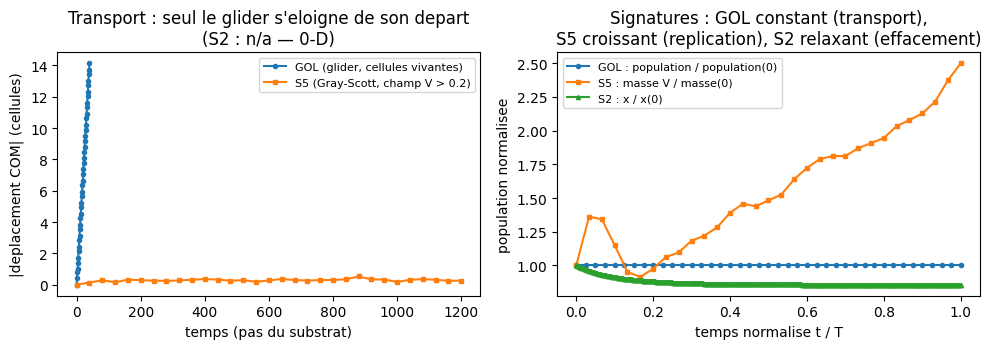

In [4]:
# Signatures de population et de transport, cote a cote.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))

t_gol = np.arange(len(gol_traj))
d_gol = np.linalg.norm(gol_com - gol_com[0], axis=1)
t_s5 = np.arange(len(snaps5)) * REC_S5
d_s5 = np.linalg.norm(s5_com - s5_com[0], axis=1)
ax1.plot(t_gol, d_gol, "o-", ms=3, label="GOL (glider, cellules vivantes)")
ax1.plot(t_s5, d_s5, "s-", ms=3, label="S5 (Gray-Scott, champ V > 0.2)")
ax1.set_xlabel("temps (pas du substrat)")
ax1.set_ylabel("|deplacement COM| (cellules)")
ax1.set_title("Transport : seul le glider s'eloigne de son depart\n(S2 : n/a — 0-D)")
ax1.legend(fontsize=8)

ax2.plot(t_gol / H_GOL, gol_pop / gol_pop[0], "o-", ms=3, label="GOL : population / population(0)")
ax2.plot(t_s5 / H_S5, s5_mass / s5_mass[0], "s-", ms=3, label="S5 : masse V / masse(0)")
ax2.plot(np.arange(len(xs_t)) / H_S2, xs_t / xs_t[0], "^-", ms=3, label="S2 : x / x(0)")
ax2.set_xlabel("temps normalise t / T")
ax2.set_ylabel("population normalisee")
ax2.set_title("Signatures : GOL constant (transport),\nS5 croissant (replication), S2 relaxant (effacement)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Lecture — trois signatures, un seul transporteur

* **GOL** : population **exactement constante** (5 cellules, `sorted(set(...)) = [5]`) pendant que le COM parcourt **(10.0, 10.0)** en 40 générations — soit `(1,1)` toutes les 4 générations, la vitesse diagonale canonique **c/4**. La forme est déplacée **intacte** : c'est la définition d'un transport d'information localisée.
* **S5** : la masse V passe de **15.7 à 39.2** (≈ ×2.5) — l'information est **répliquée** (les taches se divisent), pas transportée : le COM reste à **~0 cellule** du départ. Chaque tache reste sur place ; ce qui voyage, c'est la *frontière de colonisation*.
* **S2** : `x(t)` relaxe de 8.0 vers l'attracteur haut **6.860** — l'état initial est **effacé** au profit du point fixe. Il n'existe pas de coordonnée à déplacer : le substrat est 0-D.

L'axe T fait donc le travail de séparation attendu : **transporter (GOL) ≠ répliquer (S5) ≠ effacer (S2)**. Mais il ne dit encore rien de la *robustesse* de ces modes — c'est le rôle de l'axe R.

## 2. Axe R — réparation après `do(ablation)` (Pearl)

**Protocole commun** (celui d'ICT-11, étendu aux trois substrats) : abîmer la structure localisée par une intervention explicite `do(·)`, laisser évoluer, mesurer la fraction de structure restaurée :

* **S5** : `ict.agency.ablate` — réinitialiser un **disque de rayon 6** autour d'une tache à l'état nu (U=1, V=0), puis `recovery_score` (variance restaurée dans le masque) et `time_to_recover` ;
* **GOL** : ablation de la **cellule de tête** du glider (la cellule vivante la plus « en arrière » du sens de marche), puis **détection de pattern** (`period_and_displacement` : le glider ne survit que si la trajectoire redevient 4-périodique de déplacement (1,1)) — plus honnête qu'un simple comptage de cellules, car 6 cellules de débris ne sont pas un glider ;
* **S2** : l'ablation 0-D est un **kick** — `x ← 0.65 · x*`, puis temps de retour à 1% de l'attracteur.

S5 : ablation disque r=6 sur la tache (argmax V)
  variance reference = 0.0155 -> reparee = 0.0038
  recovery_score = 0.244   time_to_recover (85% ref) = None pas


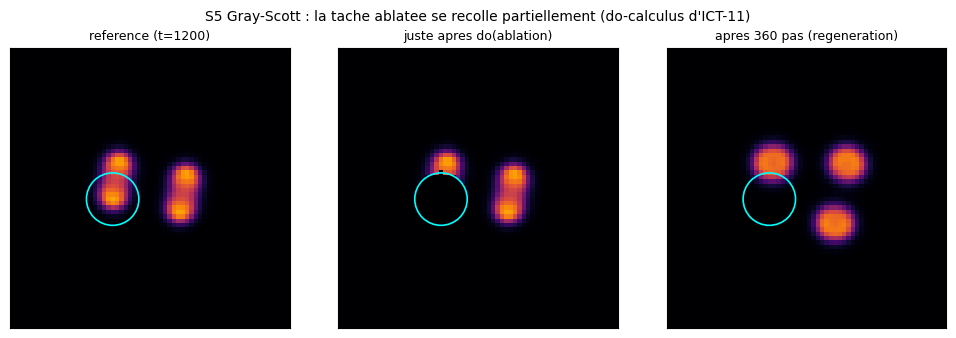

In [5]:
# --- S5 : ablation d'une tache, mesure de la regeneration ---
iy, ix = np.unravel_index(np.argmax(V_T), V_T.shape)
mask_R = disk_mask(64, float(ix), float(iy), 6.0)
s_ref5 = float(np.var(V_T[mask_R]))

U_abl5, V_abl5 = ablate(U_T, V_T, mask_R)
U_rep5, V_rep5, snaps_R5 = gs.run(U_abl5, V_abl5, 360, record_every=20, include_initial=True)
recovery5 = recovery_score(V_T, V_abl5, snaps_R5[-1], mask_R)
struct_traj5 = [float(np.var(s[mask_R])) for s in snaps_R5]
ttr5 = time_to_recover(struct_traj5, target=s_ref5, tol=0.15, record_every=20)
print(f"S5 : ablation disque r=6 sur la tache (argmax V)")
print(f"  variance reference = {s_ref5:.4f} -> reparee = {struct_traj5[-1]:.4f}")
print(f"  recovery_score = {recovery5:.3f}   time_to_recover (85% ref) = {ttr5} pas")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, field, title in zip(
    axes,
    (V_T, V_abl5, snaps_R5[-1]),
    ("reference (t=1200)", "juste apres do(ablation)", "apres 360 pas (regeneration)"),
):
    ax.imshow(field, cmap="inferno", vmin=0.0, vmax=0.5)
    ax.add_patch(plt.Circle((ix, iy), 6.0, fill=False, color="cyan", lw=1.2))
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("S5 Gray-Scott : la tache ablatee se recolle partiellement (do-calculus d'ICT-11)", fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
# --- GOL : ablation de la cellule arriere du glider, detection de pattern ---
cells_g = sorted(live_cells(g0), key=lambda c: c[0] + c[1])
arriere = cells_g[0]
site_g = disk_mask(32, float(arriere[1]), float(arriere[0]), 2.5)

g_abl = g0.copy()
g_abl[arriere[0], arriere[1]] = False
traj_abl = trajectory(g_abl, 40)
p_abl, d_abl = period_and_displacement(g_abl, max_steps=64)
recovery_gol = recovery_score(g0.astype(float), g_abl.astype(float), traj_abl[-1].astype(float), site_g)
p_intact, d_intact = period_and_displacement(g0, max_steps=64)
print(f"GOL : controle intact -> periode {p_intact}, deplacement {d_intact}")
print(f"GOL : ablation de la cellule arriere {arriere}")
print(f"  periode detectee = {p_abl}, deplacement = {d_abl}  -> glider reconstitue : {p_abl == 4 and d_abl == (1, 1)}")
print(f"  population finale = {int(traj_abl[-1].sum())} cellules (debris, pas un glider)")
print(f"  recovery_score sur le site = {recovery_gol:.3f} (le site ne redevient jamais un glider)")

GOL : controle intact -> periode 4, deplacement (1, 1)
GOL : ablation de la cellule arriere (2, 3)
  periode detectee = None, deplacement = None  -> glider reconstitue : False
  population finale = 6 cellules (debris, pas un glider)
  recovery_score sur le site = -1.167 (le site ne redevient jamais un glider)


In [7]:
# --- S2 : kick 0-D, temps de retour a 1% de l'attracteur ---
x_kick = 0.65 * x_haut
x = x_kick
t_back = None
for t in range(4000):
    if abs(x - x_haut) <= 0.01 * x_haut and t_back is None:
        t_back = t
    x = max(0.0, x + DT_S2 * float(graze.rate(x, C_BISTABLE)))
print(f"S2 : kick x* {x_haut:.3f} -> {x_kick:.3f} (-35%)")
print(f"  retour a 1% de l'attracteur haut en {t_back} pas Euler (dt = {DT_S2})")
print("  -> relaxation, pas regeneration : l'etat revient au MEME point fixe ;")
print("     aucune structure n'a ete reconstruite (il n'y en a pas).")


S2 : kick x* 6.860 -> 4.459 (-35%)
  retour a 1% de l'attracteur haut en 230 pas Euler (dt = 0.05)
  -> relaxation, pas regeneration : l'etat revient au MEME point fixe ;
     aucune structure n'a ete reconstruite (il n'y en a pas).


### Lecture — régénérative, fragile, relaxative

* **S5 est régénérative** : `recovery_score = 0.24` à horizon 360 pas — la tache ablatée **recolle partiellement** (la mitose des taches voisines re-colonise le disque), sans toutefois restaurer 85% de la variance de référence dans cet horizon (`time_to_recover = None`). Réparation **partielle et lente, mais réelle**.
* **GOL est fragile** : retirer **une seule cellule** au glider détruit le pattern — la trajectoire ne redevient jamais 4-périodique (`periode = None`), il reste des débris (6 cellules). Le `recovery_score` du site sort à **−1.17** : le site ne se reconstruit pas, il se recouvre de débris non canoniques. **Le glider transporte son information ; il ne la défend pas.**
* **S2 est relaxative** : kické à −35%, l'état revient à 1% de l'attracteur en **230 pas** — mais il n'y a rien à « réparer » : le retour au point fixe est de la dissipation de kick, pas de la reconstruction.

L'axe R inverse donc le portrait de l'axe T : le substrat qui **transporte le mieux** (GOL) est celui qui **répare le moins** — son information survit en *étant ailleurs* (translatée), pas en *se restaurant sur place*. S5 fait exactement l'inverse. Aucun des deux n'est « plus agent » : ils occupent deux cases différentes du protocole.

## 3. Axe S — enjeu : retour de bassin après kick (`I_stake`)

**Protocole commun** (`ict.stake.stake_index`) : mesurer la **fraction de distance regagnée** vers l'ancre du bassin après un kick, **moins** la même fraction sur une trajectoire libre (soustraction de la dérive spontanée) :

* **S2** : ancre = moyenne de la trajectoire stochastique libre autour du bassin haut ; kick = `do_kick` vers le bas ;
* **S5** : état = champ `V` (l'`U` voyage dans une fermeture), ancre = moyenne des derniers champs libres ; kick = l'ablation de l'axe R ;
* **GOL** : un glider **translate** — une ancre positionnelle serait battue à chaque pas par construction. Choix documenté : représenter l'état **recentré sur son COM** à chaque pas (invariant translationnel), ancre = moyenne des 4 phases recentrées du glider libre. Le kick reste l'ablation d'une cellule.

In [8]:
# --- S2 : I_stake scalaire ---
free_s2 = graze.simulate_sde(C_BISTABLE, x0=x_haut, sigma=0.02, dt=0.05, T=800, seed=7)
anchor_s2 = basin_anchor(free_s2)
step_s2 = lambda x: max(0.0, x + DT_S2 * float(graze.rate(np.asarray(x, dtype=float), C_BISTABLE)))
kicked_s2 = x_haut - 0.35 * x_haut
istake_s2 = stake_index(np.asarray(kicked_s2), step_s2, 400, anchor_s2)
print(f"S2 : ancre = {anchor_s2:.3f}, kick -35% -> I_stake = {istake_s2:.3f}")
print("     (retour actif au bassin haut : l'enjeu du bistable est un POINT)")

S2 : ancre = 6.837, kick -35% -> I_stake = 0.992
     (retour actif au bassin haut : l'enjeu du bistable est un POINT)


In [9]:
# --- S5 : I_stake sur le champ V (U porte par fermeture) ---
anchor_s5 = np.mean(np.array(snaps5[-6:]), axis=0)  # champ moyen des derniers etats libres

holder_k = {"U": U_T.copy()}
def step_v_kick(V):
    U2, V2 = gs.step(holder_k["U"], V)
    holder_k["U"] = U2
    return V2

holder_f = {"U": U_T.copy()}
def step_v_free(V):
    U2, V2 = gs.step(holder_f["U"], V)
    holder_f["U"] = U2
    return V2

kicked_s5 = V_T.copy()
kicked_s5[mask_R] = 0.0  # do(ablation) : meme intervention que l'axe R
istake_s5 = stake_index(kicked_s5, step_v_kick, 300, anchor_s5,
                        free_step_fn=step_v_free, free_init=V_T.copy())
print(f"S5 : I_stake = {istake_s5:.3f}  (kick = ablation du disque, controle libre soustrait)")
print("     (retour actif au champ de forme : l'enjeu de Gray-Scott est un MOTIF)")

S5 : I_stake = 1.000  (kick = ablation du disque, controle libre soustrait)
     (retour actif au champ de forme : l'enjeu de Gray-Scott est un MOTIF)


In [10]:
# --- GOL : I_stake sur grille recentree (invariant translationnel) ---
def recenter(grid):
    grid = np.asarray(grid).astype(bool)
    cs = live_cells(grid)
    out = np.zeros_like(grid)
    if not cs:
        return out
    ys = np.array([c[0] for c in cs], dtype=float)
    xs = np.array([c[1] for c in cs], dtype=float)
    cy, cx = int(round(ys.mean())), int(round(xs.mean()))
    for (i, j) in cs:
        out[(i - cy) % 32, (j - cx) % 32] = True
    return out

free_g = trajectory(g0, 60)
anchor_g = np.mean([recenter(g).astype(float) for g in free_g[::4]], axis=0)
step_g = lambda gr: recenter(next_generation(np.asarray(gr).astype(bool)))

# controle : kick nul -> I_stake ~ 0 par construction
istake_gol_intact = stake_index(recenter(g0).astype(float), step_g, 40, anchor_g)

g_kick1 = g0.copy()
g_kick1[arriere[0], arriere[1]] = False
istake_gol_1 = stake_index(recenter(g_kick1).astype(float), step_g, 40, anchor_g)

g_kick2 = g0.copy()
for (i, j) in cells_g[:2]:
    g_kick2[i, j] = False
istake_gol_2 = stake_index(recenter(g_kick2).astype(float), step_g, 40, anchor_g)

print(f"GOL : controle intact (kick nul)   -> I_stake = {istake_gol_intact:.3f} (attendu ~0)")
print(f"GOL : kick 1 cellule arriere       -> I_stake = {istake_gol_1:.3f}")
print(f"GOL : kick 2 cellules arriere      -> I_stake = {istake_gol_2:.3f}")
print("     (valeurs de part et d'autre de zero : l'instrument ne discrimine pas ici)")

GOL : controle intact (kick nul)   -> I_stake = 0.000 (attendu ~0)
GOL : kick 1 cellule arriere       -> I_stake = 0.286
GOL : kick 2 cellules arriere      -> I_stake = -0.167
     (valeurs de part et d'autre de zero : l'instrument ne discrimine pas ici)


### Lecture — l'instrument bassin est aveugle aux invariants translationnels

* **S2** : `I_stake = 0.99` — retour quasi complet au point. L'instrument mesure exactement ce pour quoi il a été construit : un substrat qui **défend un état**.
* **S5** : `I_stake = 1.00` (plafonné) — le champ revient vers son motif après ablation, bien au-delà de la dérive libre soustraite. Un substrat qui **défend une forme**.
* **GOL** : le contrôle intact rend bien `I_stake ≈ 0.00`, mais les kicks donnent **+0.29** (1 cellule) et **−0.17** (2 cellules) — des valeurs **de part et d'autre de zéro**, c'est-à-dire du bruit d'instrument, pas un signal d'enjeu. Et le rappel de l'axe R : dans les deux cas le glider est **détruit** (`période = None`).

C'est le point méthodologique du notebook — l'écho exact du **Gate 21 d'ICT-25** (*le détecteur ne voit pas la persona*) : `I_stake` est un instrument **bassin-return** ; l'invariant du glider est **translationnel** (sa « défense » serait de rester *une forme qui bouge*, pas de revenir *à une place*). Mesurer l'enjeu d'un substrat translatif avec une ancre de bassin, c'est pointer un thermomètre sur la lumière. La mesure honnête dit : **sur l'axe S, GOL n'a pas encore d'instrument** — en construire un (par exemple une distance entre *distributions de formes* plutôt qu'entre états) est un prolongement naturel, pas une conclusion négative.

In [11]:
# --- La table de contraste MESUREE : chaque chiffre vient des cellules ci-dessus ---
import pandas as pd

table = pd.DataFrame({
    "Mesure (protocole commun)": [
        "Transport : |deplacement COM| / horizon",
        "Population : signature temporelle",
        "Reparation : recovery_score apres do(ablation)",
        "Reparation : survie du pattern (detection 4-periodique)",
        "Enjeu : I_stake (retour de bassin)",
        "Enjeu : verdict d'instrument",
    ],
    "S2 bistable (0-D)": [
        "n/a (aucune coordonnee)",
        f"x: {xs_t[0]:.1f} -> {xs_t[-1]:.2f} (relaxation au point fixe)",
        f"relaxation : retour a 1% en {t_back} pas (kick -35%)",
        "n/a (pas de pattern)",
        f"{istake_s2:.2f}",
        "instrument OK : defend un POINT",
    ],
    "S5 Gray-Scott (2-D)": [
        f"{s5_disp:.2f} cellules / {H_S5} pas (immobile)",
        f"masse V: {s5_mass[0]:.1f} -> {s5_mass[-1]:.1f} (replication mitotique)",
        f"{recovery5:.2f} (partielle) ; ttr(85%) = {ttr5}",
        "motif persistant (taches auto-entretenues)",
        f"{istake_s5:.2f}",
        "instrument OK : defend une FORME",
    ],
    "GOL Jeu de la Vie (2-D)": [
        f"({gol_disp[0]:.0f}, {gol_disp[1]:.0f}) / {H_GOL} generations = c/4",
        f"population {gol_pop[0]} constante (transport intact)",
        f"{recovery_gol:.2f} (site recouvert de debris)",
        f"DETRUIT par l'ablation d'1 cellule (periode = None)",
        f"{istake_gol_1:+.2f} / {istake_gol_2:+.2f} (bruit d'instrument)",
        "instrument AVEUGLE : invariant translationnel",
    ],
}).set_index("Mesure (protocole commun)")
table

,S2 bistable (0-D),S5 Gray-Scott (2-D),GOL Jeu de la Vie (2-D)
Mesure (protocole commun),,,
Transport : |deplacement COM| / horizon,n/a (aucune coordonnee),0.26 cellules / 1200 pas (immobile),"(10, 10) / 40 generations = c/4"
Population : signature temporelle,x: 8.0 -> 6.86 (relaxation au point fixe),masse V: 15.7 -> 39.2 (replication mitotique),population 5 constante (transport intact)
Reparation : recovery_score apres do(ablation),relaxation : retour a 1% en 230 pas (kick -35%),0.24 (partielle) ; ttr(85%) = None,-1.17 (site recouvert de debris)
Reparation : survie du pattern (detection 4-periodique),n/a (pas de pattern),motif persistant (taches auto-entretenues),DETRUIT par l'ablation d'1 cellule (periode = ...
Enjeu : I_stake (retour de bassin),0.99,1.00,+0.29 / -0.17 (bruit d'instrument)
Enjeu : verdict d'instrument,instrument OK : defend un POINT,instrument OK : defend une FORME,instrument AVEUGLE : invariant translationnel


### Lecture — un profil, pas un classement

La table se lit en colonnes, et chaque colonne est un **mode de relation à l'information** :

| | S2 | S5 | GOL |
|---|---|---|---|
| **Mode** | effacer | régénérer | transporter |
| **L'information survit…** | comme un bit (bassin choisi) | en se recollant sur place | en étant ailleurs |
| **Faiblesse mesurée** | aucun espace | immobile | fragile à l'impact direct |
| **Instrument qui la voit** | I_stake ✓ | I_stake + recovery ✓ | period/displacement ✓ — I_stake ✗ |

Aucun axe ne dit « GOL gagne » : l'axe T le distingue (seul transporteur), l'axe R le distingue **en défaveur** (seul non-réparateur), l'axe S ne le voit pas. C'est exactement ce qu'un banc discriminant doit produire : **une signature par substrat**, et la connaissance précise de ce que chaque instrument ne voit pas — condition pour ne pas construire la suite (émergence causale, tranche en cours sur les mêmes trajectoires) sur un aveugle.

### Exercice 1 — balayage d'ablation du glider : position et taille

La cellule de l'axe R n'a testé que la cellule « arrière ». Balayez **toutes** les cellules du glider × toutes les tailles d'ablation (1, 2, 3 cellules) : pour chaque configuration, déterminez si la trajectoire redonne un glider (période 4, déplacement (1,1)).

**Question** : le taux de survie dépend-il de la *position* des cellules retirées (tête vs queue vs flanc) ? Une ablation de 2 cellules « symétriques » survit-elle mieux que 2 cellules adjacentes ?

*Indice* : `sorted(live_cells(g0), key=...)` donne les candidats ; `itertools.combinations` énumère les ensembles ; `period_and_displacement(g, max_steps=64)` rend le verdict.

In [12]:
# Etape 1 : enumerer toutes les combinaisons de 1, 2 et 3 cellules du glider initial.
# Etape 2 : pour chaque combinaison, ablater puis evoluer et tester (periode=4, deplacement=(1,1)).
# Etape 3 : agregger par taille -> taux de survie ; par position -> effet tete/queue.
def taux_survie_ablation(horizon=40):
    result = None  # TODO etudiant : dict {taille: taux_survie} + detail par position
    return result

print("Exercice a completer : taux_survie_ablation")

Exercice a completer : taux_survie_ablation


### Exercice 2 — dose-réponse du Gray-Scott : le paramètre feed `F`

Le régime mitotique (F = 0.0367) n'est qu'un point de l'espace (F, k). Pour une petite grille de valeurs de `F` (par ex. 0.030, 0.0367, 0.045, 0.055, à k fixe), faites pousser le substrat avec le protocole de l'axe T, **comptez les taches** formées à horizon fixe, puis mesurez le `recovery_score` après ablation d'une tache (protocole de l'axe R).

**Question** : la capacité de régénération a-t-elle un seuil en `F` ? Le régime qui régénère le mieux est-il celui qui a le plus de taches ?

*Indice* : compter les taches = composantes connexes du champ seuillé `V > 0.3` (un parcours en profondeur ou en largeur suffit sur une grille 64×64) ; réutilisez `disk_mask` + `recovery_score` telles quelles.

In [13]:
# Etape 1 : pour chaque F de la grille, seed + run (memes parametres que l'axe T) a horizon fixe.
# Etape 2 : compter les composantes connexes de V > 0.3 (les taches).
# Etape 3 : ablater la tache la plus brillante et mesurer recovery_score (protocole axe R).
def dose_reponse_F(F_grid=(0.030, 0.0367, 0.045, 0.055), steps=1200, rayon=6.0):
    result = None  # TODO etudiant : liste de dicts {F, nb_taches, recovery_score}
    return result

print("Exercice a completer : dose_reponse_F")

Exercice a completer : dose_reponse_F


### Exercice 3 — hystérésis du bistable : la mémoire de chemin comme « transport » 0-D

L'axe T a mesuré que S2 ne transporte rien dans l'espace — mais le bistable transporte quelque chose **le long du paramètre** : faites **monter** `c` de 1.5 à 3.5 puis **redescendre** de 3.5 à 1.5 (rampe lente, `simulate_ramp`), en partant chaque fois du bassin haut.

**Question** : le seuil de bascule à la montée (`c↑`) et celui à la descente (`c↓`) coïncident-ils ? L'écart entre les deux est l'**hystérésis** — la trace laissée par l'histoire du trajet, seul « transport d'information » d'un substrat sans espace.

*Indice* : détectez la bascule quand `x` passe sous 2.0 ; comparez le `c` de bascule montée vs descente ; un `sigma = 0.0` rend l'expérience déterministe.

In [14]:
# Etape 1 : rampe montee c: 1.5 -> 3.5 (simulate_ramp, x0 = bassin haut, sigma = 0).
# Etape 2 : rampe descente c: 3.5 -> 1.5 en repartant du bassin haut.
# Etape 3 : detecter les deux seuils (x < 2.0) et rapporter l'ecart = hysteresis.
def seuils_hysteresis(c_lo=1.5, c_hi=3.5, n=6000):
    result = None  # TODO etudiant : dict {"c_montee": ..., "c_descente": ..., "ecart": ...}
    return result

print("Exercice a completer : seuils_hysteresis")

Exercice a completer : seuils_hysteresis


## Conclusion — ce que le contraste mesure, et ce qu'il laisse ouvert

Ce notebook a exécuté **le même protocole** sur les trois substrats de la batterie ICT, et la table mesurée établit le profil annoncé par le dispatch #5726 :

1. **GOL est le seul transporteur** — population constante, COM à c/4, forme intacte (axe T) ;
2. **GOL est le seul non-réparateur** — une cellule retirée détruit le glider, sans régénération ; S5 recolle partiellement, S2 relaxe (axe R) ;
3. **L'instrument d'enjeu `I_stake` voit S2 et S5, pas GOL** — l'invariant du glider est translationnel ; la mesure honnête de cet axe est la *déclaration* de cet aveugle (axe S).

Ce que ce notebook ne fait pas : l'**émergence causale** (TPM coarse-grainée, information effective) sur ces trajectoires — c'est l'objet de la tranche en cours sur les trajectoires certifiées (issue #5726), à laquelle ce contraste fournit le socle des trois régimes. Les mono-substrats se creusent dans leurs notebooks respectifs : [ICT-8](ICT-8-AttractorLandscapesEWS.ipynb) (paysages et early-warning du bistable), ICT-9 (morphogenèse Gray-Scott), [ICT-Life](ICT-Life-SubstratCertifie.ipynb) (calibration GOL + pont Lean `hashlife_correct`).

*Suite naturelle : un instrument d'enjeu translationnel (distance entre distributions de formes), et le croisement de cette table avec l'information effective des trajectoires certifiées.*